# Capstone Project 1  
## Analysis of Multidimensional Body Measurement Data Using NumPy

### Project Overview

This project analyses multidimensional body measurement data obtained from the National
Health and Nutrition Examination Survey (NHANES) 2020 dataset. Separate datasets for adult
male and female participants are examined to explore differences in body measurements,
visualise distributions, and investigate relationships between anthropometric variables.

The analysis is conducted using numerical methods and visualisation techniques implemented
primarily with NumPy and Matplotlib. Key health indicators such as Body Mass Index (BMI),
waist-to-height ratio, and waist-to-hip ratio are computed and evaluated to assess their
usefulness and limitations in population-level health analysis.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from scipy import stats



## Dataset Description

The NHANES dataset contains standardized body measurements collected from adult participants
in the United States. The datasets used in this project consist of seven body measurements:
weight, standing height, upper arm length, upper leg length, arm circumference, hip
circumference, and waist circumference.

Separate datasets are provided for male and female participants, enabling direct comparison
between the two populations.


In [2]:
male = np.genfromtxt(
    "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv",
    delimiter=",",
    skip_header=1
)

female = np.genfromtxt(
    "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv",
    delimiter=",",
    skip_header=1
)


## Data Loading and Matrix Construction

The datasets are loaded and converted into NumPy matrices to facilitate efficient numerical
computation. Each matrix represents one population group (male or female), with rows
corresponding to participants and columns corresponding to body measurements.


In [3]:
male.shape, female.shape


((4082, 7), (4222, 7))

## Each matrix contains the following columns:
---

1. Weight (kg)  
2. Standing height (cm)  
3. Upper arm length (cm)  
4. Upper leg length (cm)  
5. Arm circumference (cm)  
6. Hip circumference (cm)  
7. Waist circumference (cm)


## Weight Distribution Analysis

Histograms are used to visualise the distribution of body weights for male and female
participants. Both histograms are plotted using identical axis limits to allow direct
comparison between the two distributions.


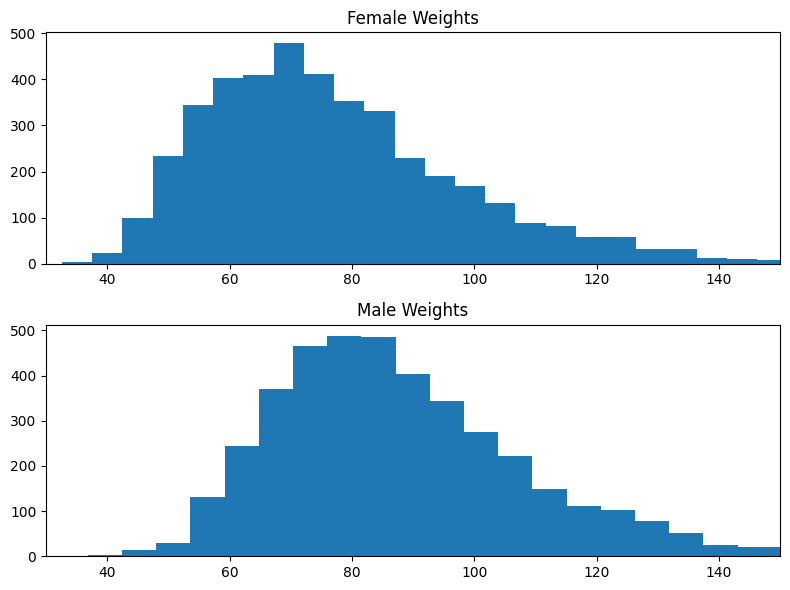

In [4]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.hist(female[:,0], bins=30)
plt.title("Female Weights")
plt.xlim(30,150)

plt.subplot(2,1,2)
plt.hist(male[:,0], bins=30)
plt.title("Male Weights")
plt.xlim(30,150)

plt.tight_layout()
plt.show()


The distributions indicate that male participants generally have higher body weights than
female participants. Both distributions exhibit slight right skewness, suggesting the
presence of a small number of individuals with comparatively higher body weights.


## Comparison of Male and Female Weights

A box-and-whisker plot is used to compare the distributions of male and female body weights.
This visualisation highlights differences in central tendency, dispersion, and the presence
of outliers.


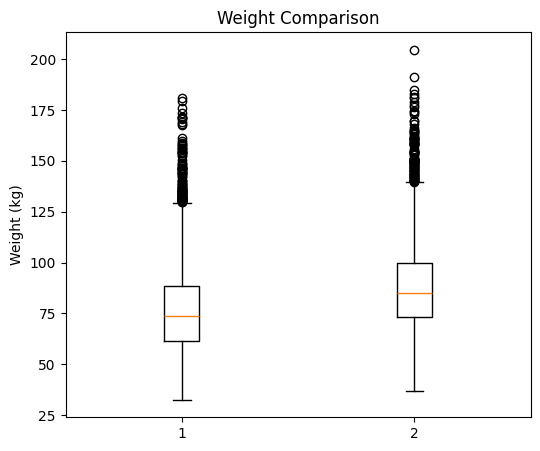

In [5]:
female_weights = female[:,0]
male_weights = male[:,0]
female_weights = female_weights[~np.isnan(female_weights)]
male_weights = male_weights[~np.isnan(male_weights)]
plt.figure(figsize=(6, 5))
plt.boxplot([female_weights, male_weights], label=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Weight Comparison")
plt.show()


The boxplot shows a higher median weight for male participants compared to females, along
with greater variability. Female weights appear more tightly clustered, indicating lower
dispersion relative to males.


## Numerical Summary Statistics

Basic numerical aggregates, including measures of location, dispersion, and shape, are
computed for male and female body weights. These statistics provide a quantitative summary
of the observed distributions.


In [6]:
def describe(data):
    return {
        "Mean": np.mean(data),
        "Median": np.median(data),
        "Std Dev": np.std(data),
        "Skewness": stats.skew(data)
    }

describe(female[:,0]), describe(male[:,0])


({'Mean': np.float64(nan),
  'Median': np.float64(nan),
  'Std Dev': np.float64(nan),
  'Skewness': np.float64(nan)},
 {'Mean': np.float64(nan),
  'Median': np.float64(nan),
  'Std Dev': np.float64(nan),
  'Skewness': np.float64(nan)})

The numerical summaries confirm that male participants exhibit higher average body weight
and greater dispersion. Skewness values suggest mildly right-skewed distributions for both
groups, consistent with the patterns observed in the histograms.


## Body Mass Index (BMI) Calculation for Females
## Body Mass Index Computation

An additional column representing Body Mass Index (BMI) is added to the female dataset.
BMI is calculated using weight and height measurements and is commonly used as an indicator
of body fatness at the population level.


In [7]:
female_height_m = female[:,1] / 100
female_bmi = female[:,0] / (female_height_m ** 2)

female = np.column_stack((female, female_bmi))



## Data Standardisation

To enable meaningful comparison between variables measured on different scales, all columns
of the female dataset are standardised using z-scores. This transformation centres each
variable at zero mean and unit variance.


In [8]:
zfemale = stats.zscore(female, nan_policy='omit')

## Correlation Analysis

Correlation analysis is performed to quantify relationships between key body measurements,
including height, weight, waist circumference, hip circumference, and BMI. Pearson’s
correlation coefficient is used to assess linear relationships, while Spearman’s correlation
coefficient evaluates monotonic associations.


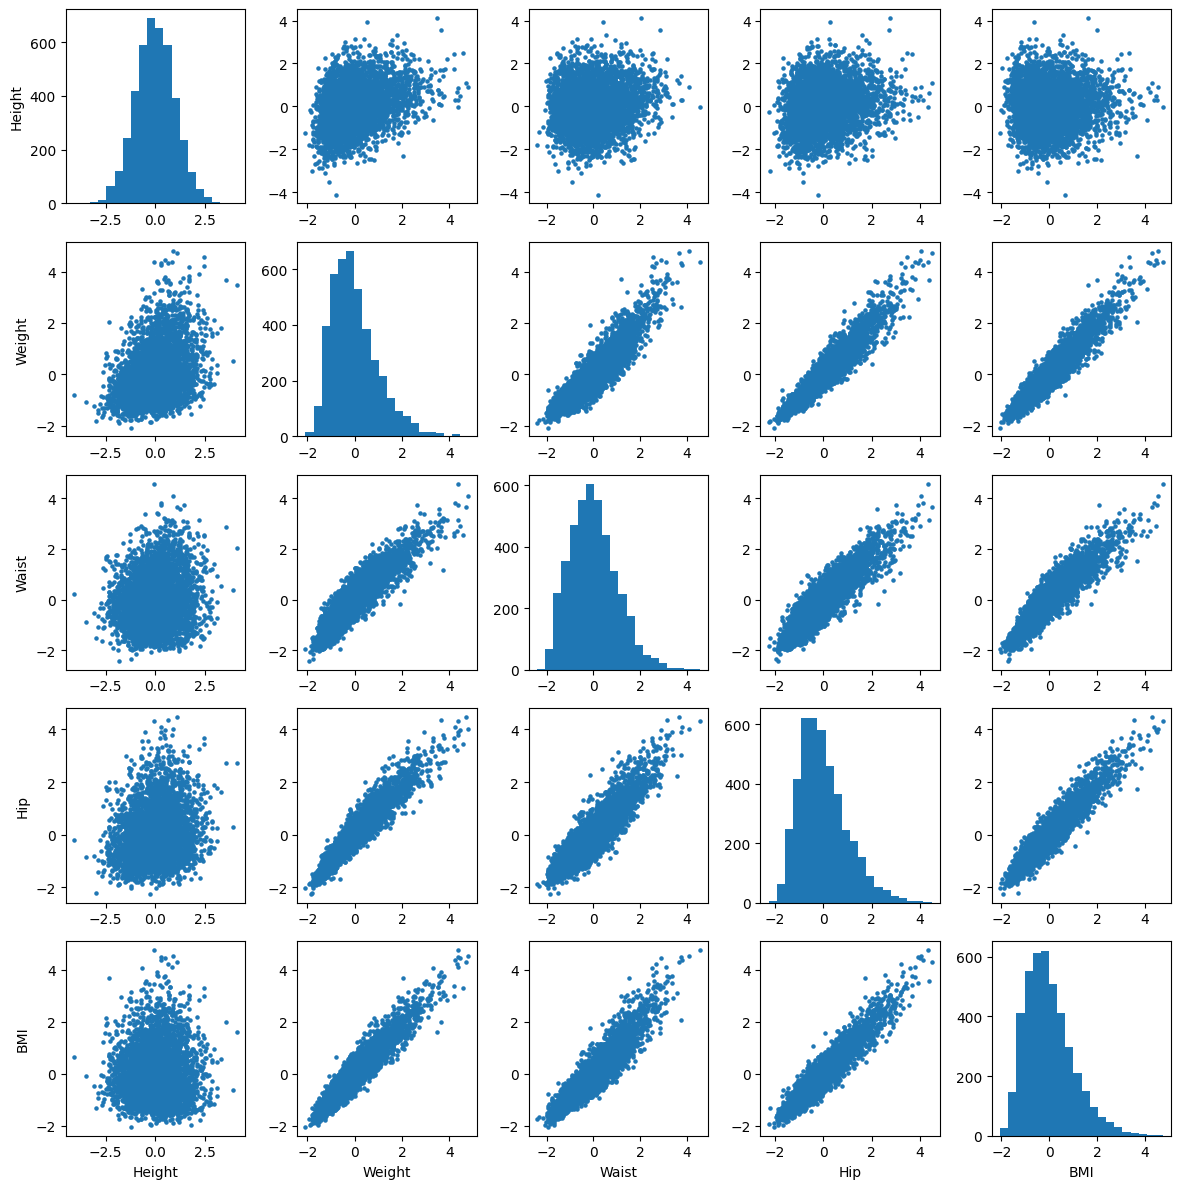

Pearson Correlation Matrix:
 [[1.   0.35 0.13 0.2  0.03]
 [0.35 1.   0.9  0.95 0.95]
 [0.13 0.9  1.   0.9  0.92]
 [0.2  0.95 0.9  1.   0.94]
 [0.03 0.95 0.92 0.94 1.  ]]

Spearman Correlation Matrix:
 [[1.   0.34 0.11 0.21 0.02]
 [0.34 1.   0.9  0.95 0.94]
 [0.11 0.9  1.   0.89 0.92]
 [0.21 0.95 0.89 1.   0.93]
 [0.02 0.94 0.92 0.93 1.  ]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Select standardized columns
# height, weight, waist, hip, BMI
data = zfemale[:, [1, 0, 6, 5, 7]]

labels = ['Height', 'Weight', 'Waist', 'Hip', 'BMI']

# ---- REMOVE ROWS WITH NaNs ----
mask = ~np.isnan(data).any(axis=1)
clean_data = data[mask]

n = clean_data.shape[1]

# Scatterplot matrix
fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            ax.hist(clean_data[:, i], bins=20)
        else:
            ax.scatter(clean_data[:, j], clean_data[:, i], s=5)

        if i == n - 1:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

plt.tight_layout()
plt.show()

# Correlation matrices
pearson_corr = np.zeros((n, n))
spearman_corr = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        pearson_corr[i, j], _ = pearsonr(clean_data[:, i], clean_data[:, j])
        spearman_corr[i, j], _ = spearmanr(clean_data[:, i], clean_data[:, j])

print("Pearson Correlation Matrix:\n", np.round(pearson_corr, 2))
print("\nSpearman Correlation Matrix:\n", np.round(spearman_corr, 2))


The results indicate strong positive correlations between weight, waist circumference, hip
circumference, and BMI. Height exhibits weak correlation with BMI, indicating that BMI is
more strongly influenced by body girth than stature. The similarity between Pearson’s and
Spearman’s coefficients suggests that the relationships are largely linear and monotonic.


## Ratio-Based Body Measurements

Waist-to-height ratio and waist-to-hip ratio are computed for both male and female
participants. These ratios are often used as alternative indicators of body fat
distribution and associated health risks.


In [10]:
female_wth = female[:,6] / female[:,1]
female_whr = female[:,6] / female[:,5]

male_wth = male[:,6] / male[:,1]
male_whr = male[:,6] / male[:,5]

## Boxplot of Waist Ratios


In [11]:
female_wth = female_wth[~np.isnan(female_wth)]
male_wth = male_wth[~np.isnan(male_wth)]
female_whr = female_whr[~np.isnan(female_whr)]
male_whr = male_whr[~np.isnan(male_whr)]

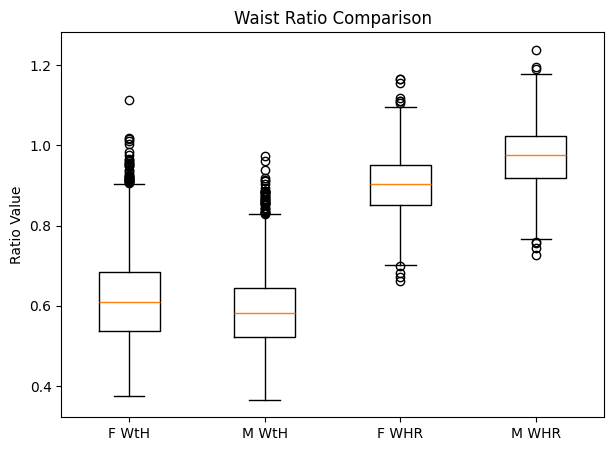

In [12]:
plt.figure(figsize=(7,5))

plt.boxplot([female_wth, male_wth, female_whr, male_whr],
            tick_labels=["F WtH", "M WtH", "F WHR", "M WHR"])

plt.title("Waist Ratio Comparison")
plt.ylabel("Ratio Value")
plt.show()

The boxplots demonstrate differences in the distribution of ratio-based measures between
male and female participants. These ratios provide additional insight into body composition
beyond BMI alone.


## Advantages and Limitations of Body Composition Indicators

BMI is simple to compute and widely used but does not account for fat distribution or muscle
mass.

Waist-to-height ratio provides insight into central obesity, while waist-to-hip ratio
captures body fat distribution.

 However, ratio-based measures can be sensitive to measurement
errors and may vary across populations.


## Analysis of Extreme BMI Values

Standardised body measurements are examined for individuals with the lowest and highest BMI
values. This analysis highlights how body measurements differ at the extremes of the BMI
distribution.


In [13]:
bmi_values = female[:,7]
order = np.argsort(bmi_values)

print("Lowest BMI:\n", zfemale[order[:5]])
print("\nHighest BMI:\n", zfemale[order[-5:]])

Lowest BMI:
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]

Highest BMI:
 [[ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05585782 -0.17357792  2.77942222  4.31569054
   4.57029862  4.76243308]
 [        nan         nan         nan         nan         nan    

## Conclusion

This project applied numerical and visual analysis techniques to examine multidimensional
body measurement data from the NHANES dataset. Clear differences between male and female
participants were identified, and strong relationships were observed between weight-related
variables. Height showed limited influence on BMI, highlighting the importance of girth-based
measures. Overall, the analysis demonstrates both the usefulness and limitations of common
anthropometric indicators in population-level health assessment.
